# Lista de Exercícios – Regressão Linear com Base de Logística

## Problema: prever tempo de entrega

Neste notebook, vamos trabalhar com uma base simulada de uma empresa de entregas.

A empresa quer prever o **tempo de entrega em minutos** com base em características do pedido e da entrega.

## Objetivo geral

Criar modelos de regressão linear para prever:

> quanto tempo uma entrega deve demorar.

Essa é uma aplicação mais próxima de problemas reais de empresas, e-commerce, logística e sistemas de roteirização.

# Contexto da base

Cada linha representa um pedido entregue.

## Colunas

| Coluna | Descrição |
|---|---|
| id_pedido | Identificador do pedido |
| distancia_km | Distância entre loja/centro de distribuição e cliente |
| peso_kg | Peso total do pedido |
| qtd_itens | Quantidade de itens no pedido |
| valor_pedido | Valor total do pedido |
| trafego | Condição do tráfego: baixo, medio ou alto |
| clima | Condição climática: normal, chuva ou forte_chuva |
| tipo_entrega | normal ou expressa |
| regiao | centro, bairro ou zona_rural |
| tempo_entrega_min | Tempo de entrega em minutos |
| atrasou | Indica se a entrega passou de 120 minutos |

## Variável alvo para regressão

A variável que queremos prever é:

`tempo_entrega_min`

# Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Agora, para ler o arquivo, você precisará usar o caminho completo dentro do seu Drive:
# caminho_do_arquivo = '/content/drive/MyDrive/Colab Notebook/base_logistica_entregas.csv'
# df = pd.read_csv(caminho_do_arquivo)

Mounted at /content/drive


In [3]:
import pandas as pd

# Ajuste o caminho do arquivo para o local correto no seu Google Drive
caminho_do_arquivo = '/content/drive/MyDrive/Colab Notebooks/base_logistica_entregas.csv'
df = pd.read_csv(caminho_do_arquivo)

Após executar a célula acima, você receberá um prompt para autorizar o Colab a acessar seu Google Drive. Siga as instruções e cole o código de autorização quando solicitado.

In [4]:
df

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
...,...,...,...,...,...,...,...,...,...,...,...
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim


# Criando a base de dados

# Parte A – Exploração inicial da base

## Exercício 1
Mostre as 10 primeiras linhas da base.

## Exercício 2
Mostre as 10 últimas linhas da base.

## Exercício 3
Use `.info()` para verificar os tipos de dados.

## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.

## Exercício 5
Verifique se há valores nulos.

## Exercício 6
Quantas linhas e colunas existem?

## Exercício 7
Qual é a variável alvo do problema de regressão?

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?

## Exercício 9
Quais variáveis são categóricas?

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?

In [5]:
# A 01
#Mostre as 10 primeiras linhas da base
df.head(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
5,6,34.4,17.3,2,301.96,baixo,forte_chuva,normal,zona_rural,168,sim
6,7,78.5,3.3,10,2048.23,medio,normal,expressa,bairro,196,sim
7,8,55.1,21.1,1,443.68,baixo,normal,normal,centro,157,sim
8,9,39.0,19.9,8,1349.17,medio,normal,expressa,centro,158,sim
9,10,32.0,1.7,6,982.79,medio,normal,normal,centro,122,sim


In [6]:
# A 02
#Mostre as 10 últimas linhas da base.
df.tail(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
190,191,17.3,2.8,4,1323.99,baixo,chuva,expressa,centro,61,nao
191,192,57.7,10.5,9,1929.33,medio,chuva,normal,bairro,212,sim
192,193,30.9,28.3,1,1558.34,medio,chuva,normal,zona_rural,175,sim
193,194,53.8,14.8,9,1268.27,medio,forte_chuva,normal,centro,235,sim
194,195,3.3,8.3,1,1504.90,medio,normal,normal,zona_rural,73,nao
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim
199,200,10.6,25.4,6,2290.93,medio,normal,normal,centro,133,sim


In [7]:
# A 03
#Use .info() para verificar os tipos de dados.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pedido          200 non-null    int64  
 1   distancia_km       200 non-null    float64
 2   peso_kg            200 non-null    float64
 3   qtd_itens          200 non-null    int64  
 4   valor_pedido       200 non-null    float64
 5   trafego            200 non-null    object 
 6   clima              200 non-null    object 
 7   tipo_entrega       200 non-null    object 
 8   regiao             200 non-null    object 
 9   tempo_entrega_min  200 non-null    int64  
 10  atrasou            200 non-null    object 
dtypes: float64(3), int64(3), object(5)
memory usage: 17.3+ KB


In [8]:
# A 04
# Use .describe() para analisar as variáveis numéricas.
df.describe()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,40.757500,14.814500,5.950000,1343.555900,158.355000
std,57.879185,21.046217,8.801453,3.081392,718.343381,49.450437
min,1.000000,1.200000,0.300000,1.000000,35.170000,44.000000
25%,50.750000,25.075000,7.300000,3.000000,705.650000,126.000000
50%,100.500000,42.150000,14.050000,6.000000,1352.880000,158.500000
75%,150.250000,57.725000,22.800000,8.250000,1934.770000,189.250000
max,200.000000,79.600000,29.900000,11.000000,2489.780000,286.000000


In [9]:
# A 05
#Verifique se há valores nulos.
df.isnull().sum()

,0
id_pedido,0
distancia_km,0
peso_kg,0
qtd_itens,0
valor_pedido,0
trafego,0
clima,0
tipo_entrega,0
regiao,0
tempo_entrega_min,0


In [10]:
# A 06
#Quantas linhas e colunas existem?
df.shape

(200, 11)

In [11]:
# A 07
#Qual é a variável alvo do problema de regressão?
df.columns

Index(['id_pedido', 'distancia_km', 'peso_kg', 'qtd_itens', 'valor_pedido',
       'trafego', 'clima', 'tipo_entrega', 'regiao', 'tempo_entrega_min',
       'atrasou'],
      dtype='object')

In [12]:
# A 08
#Quais variáveis parecem ser boas candidatas para prever tempo de entrega?
df.columns
# todas as Colunas


Index(['id_pedido', 'distancia_km', 'peso_kg', 'qtd_itens', 'valor_pedido',
       'trafego', 'clima', 'tipo_entrega', 'regiao', 'tempo_entrega_min',
       'atrasou'],
      dtype='object')

In [13]:
# A 09
# Quais variáveis são categóricas?
#df.columns
df.select_dtypes(include=['object','category']).columns

Index(['trafego', 'clima', 'tipo_entrega', 'regiao', 'atrasou'], dtype='object')

In [19]:
# A 10
# Regressão só trabalha com números
# Converter para números simples cria ordem falsa
# Precisamos transformar em colunas binárias (One-Hot)

# Parte B – Estatística descritiva

## Exercício 11
Calcule a média do tempo de entrega.

## Exercício 12
Calcule a mediana do tempo de entrega.

## Exercício 13
Calcule o desvio padrão do tempo de entrega.

## Exercício 14
Calcule o tempo mínimo e máximo de entrega.

## Exercício 15
Calcule os quartis de `tempo_entrega_min`.

## Exercício 16
Interprete a diferença entre média e mediana.

## Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

## Exercício 18
Existe algum possível outlier no tempo de entrega?

## Exercício 19
Compare o tempo médio de entrega por tipo de entrega.

## Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

In [14]:
# Espaço para resolver a Parte B
# B 11
#Calcule a média do tempo de entrega.
df['tempo_entrega_min'].mean()

np.float64(158.355)

In [15]:
# B 12
#Calcule a mediana do tempo de entrega.
df['tempo_entrega_min'].median()

158.5

In [26]:
# B 13
#Calcule o desvio padrão do tempo de entrega.
df['tempo_entrega_min'].std()

49.45043683849101

In [16]:
# B 14
# Calcule o tempo mínimo e máximo de entrega
print(df['tempo_entrega_min'].min())
print(df['tempo_entrega_min'].max())


44
286


In [17]:
# B 15
# Calcule os quartis de `tempo_entrega_min`.
df['tempo_entrega_min'].quantile([0.25, 0.5, 0.75])

,tempo_entrega_min
0.25,126.00
0.50,158.50
0.75,189.25


In [18]:
# B 16
#Interprete a diferença entre média e mediana
df['tempo_entrega_min'].mean() - df['tempo_entrega_min'].median()
# A média é ligeiramente menor que a mediana, indicando uma leve assimetria à esquerda causada por alguns tempos de entrega menores.
# Como a diferença é muito pequena, a distribuição pode ser considerada aproximadamente simétrica.

np.float64(-0.14500000000001023)

In [19]:
# B 17
#Existe muita variação nos tempos de entrega?
desvio = df['tempo_entrega_min'].std()

print("Desvio padrão:", desvio)
print("Existe muita variação nos tempos de entrega.")

Desvio padrão: 49.45043683849101
Existe muita variação nos tempos de entrega.


In [20]:
# B 18
Q1 = df['tempo_entrega_min'].quantile(0.25)
Q3 = df['tempo_entrega_min'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['tempo_entrega_min'] < limite_inferior) |
              (df['tempo_entrega_min'] > limite_superior)]

print("Quantidade de outliers:", len(outliers))

Quantidade de outliers: 1


In [21]:
# B 19
df.groupby('tipo_entrega')['tempo_entrega_min'].mean()

,tempo_entrega_min
tipo_entrega,
expressa,149.894737
normal,161.727273


In [33]:
# B 20
media_trafego = df.groupby('trafego')['tempo_entrega_min'].mean()
print(media_trafego)
#Existe uma relação clara entre tráfego e tempo de entrega:

#Quando o tráfego é alto, o tempo médio é o maior.
#Quando o tráfego é baixo, o tempo médio é o menor.
#O tráfego médio fica entre os dois.

#Ou seja, quanto maior o tráfego, maior o tempo de entrega.

trafego
alto     188.075000
baixo    135.119403
medio    162.311828
Name: tempo_entrega_min, dtype: float64


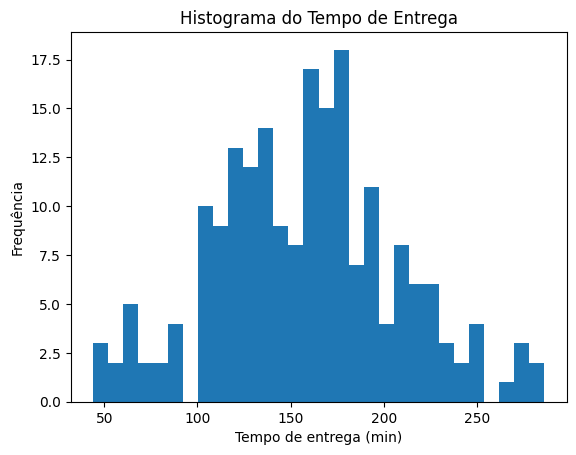

In [22]:
# Espaço para resolver a Parte C
# C 21

plt.hist(df['tempo_entrega_min'], bins=30)
plt.title('Histograma do Tempo de Entrega')
plt.xlabel('Tempo de entrega (min)')
plt.ylabel('Frequência')

plt.show()
#O histograma mostra que a maior parte dos tempos de entrega está concentrada entre aproximadamente 130 e 190 minutos.
#A distribuição apresenta leve assimetria à direita, indicando a presença de algumas entregas muito demoradas que aumentam a dispersão dos dados.

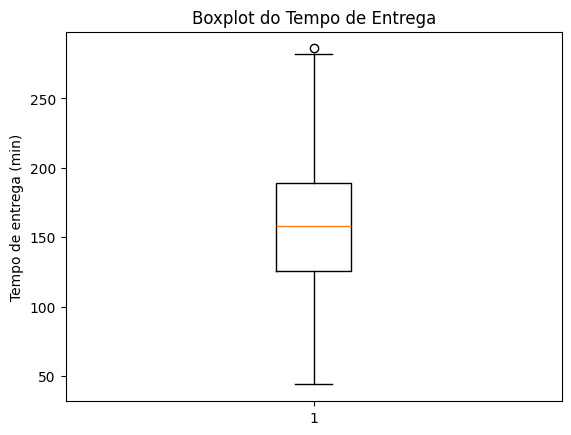

In [23]:
# C 22
#import matplotlib.pyplot as plt

plt.boxplot(df['tempo_entrega_min'])
plt.title('Boxplot do Tempo de Entrega')
plt.ylabel('Tempo de entrega (min)')

plt.show()
#O boxplot mostra que a maior parte dos tempos de entrega está entre aproximadamente 125 e 190 minutos, com mediana próxima de 160 minutos.
#O gráfico também evidencia a presença de outliers superiores, indicando algumas entregas muito mais demoradas que o padrão.

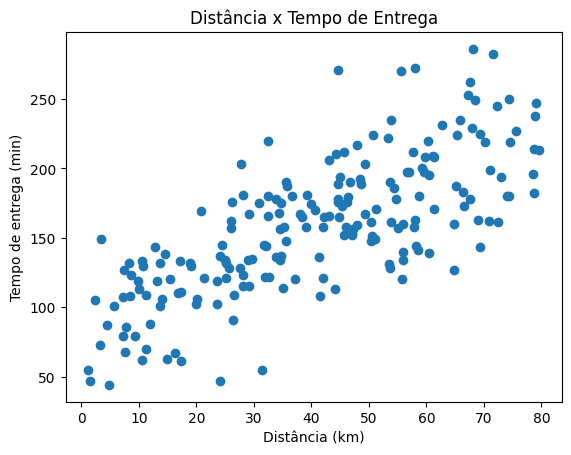

In [24]:
# C 23

plt.scatter(df['distancia_km'], df['tempo_entrega_min'])
plt.title('Distância x Tempo de Entrega')
plt.xlabel('Distância (km)')
plt.ylabel('Tempo de entrega (min)')

plt.show()

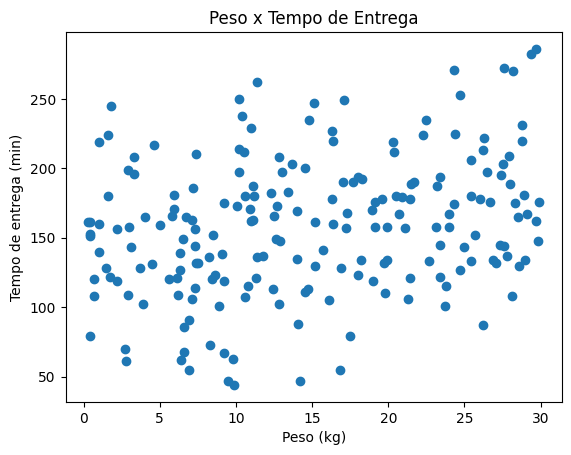

In [25]:
# C 24

plt.scatter(df['peso_kg'], df['tempo_entrega_min'])
plt.title('Peso x Tempo de Entrega')
plt.xlabel('Peso (kg)')
plt.ylabel('Tempo de entrega (min)')

plt.show()

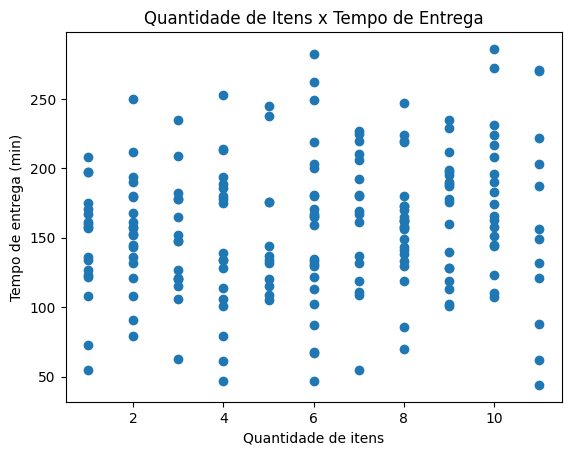

In [26]:
# C 25

plt.scatter(df['qtd_itens'], df['tempo_entrega_min'])
plt.title('Quantidade de Itens x Tempo de Entrega')
plt.xlabel('Quantidade de itens')
plt.ylabel('Tempo de entrega (min)')

plt.show()

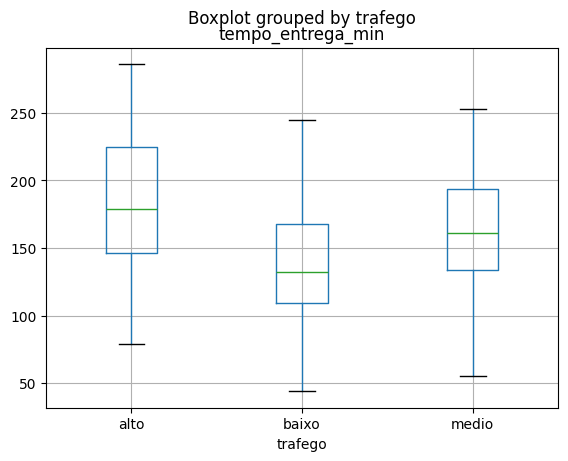

In [27]:
# C 26

df.boxplot(column='tempo_entrega_min', by='trafego')
plt.show()

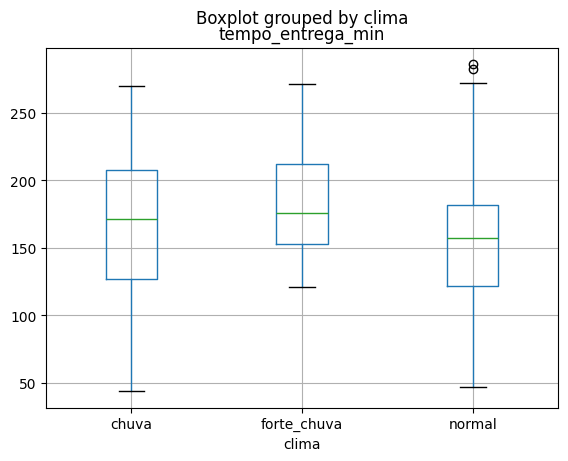

In [28]:
# C 27
df.boxplot(column='tempo_entrega_min', by='clima')
plt.show()

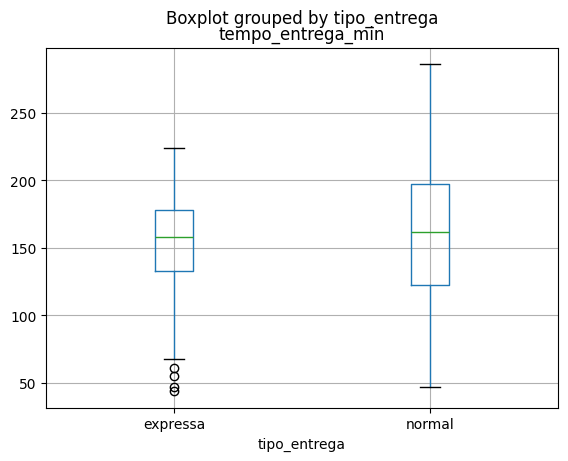

In [30]:
# C 28
df.boxplot(column='tempo_entrega_min', by='tipo_entrega')
plt.show()

In [42]:
# C 29
#Grafico do exercicio 23 Distacia e tempo de entrega

In [43]:
# C 30
#Sim, sugere uma relação aproximadamente linear positiva.

# Parte C – Visualização

## Exercício 21
Faça um histograma de `tempo_entrega_min`.

## Exercício 22
Faça um boxplot de `tempo_entrega_min`.

## Exercício 23
Faça um gráfico de dispersão entre `distancia_km` e `tempo_entrega_min`.

## Exercício 24
Faça um gráfico de dispersão entre `peso_kg` e `tempo_entrega_min`.

## Exercício 25
Faça um gráfico de dispersão entre `qtd_itens` e `tempo_entrega_min`.

## Exercício 26
Faça um boxplot de tempo de entrega por `trafego`.

## Exercício 27
Faça um boxplot de tempo de entrega por `clima`.

## Exercício 28
Faça um boxplot de tempo de entrega por `tipo_entrega`.

## Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

## Exercício 30
O gráfico sugere relação linear entre distância e tempo?

# Parte D – Correlação

Para calcular correlação, use apenas variáveis numéricas.

## Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

## Exercício 32
Calcule a matriz de correlação.

## Exercício 33
Faça um heatmap da matriz de correlação.

## Exercício 34
Qual variável numérica tem maior correlação positiva com `tempo_entrega_min`?

## Exercício 35
Qual variável numérica parece ter menor relação com `tempo_entrega_min`?

## Exercício 36
Correlação alta prova causalidade? Explique.

## Exercício 37
Se `valor_pedido` tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.

## Exercício 38
A variável `distancia_km` parece importante? Justifique.

## Exercício 39
A variável `peso_kg` parece importante? Justifique.

## Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

In [31]:
# Espaço para resolver a Parte D
# D
df.corr(numeric_only=True)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
id_pedido,1.000000,-0.010864,0.020593,-0.034910,0.036968,0.014440
distancia_km,-0.010864,1.000000,-0.020853,-0.039094,-0.073556,0.743120
peso_kg,0.020593,-0.020853,1.000000,0.016054,-0.037019,0.280642
qtd_itens,-0.034910,-0.039094,0.016054,1.000000,0.132516,0.156666
valor_pedido,0.036968,-0.073556,-0.037019,0.132516,1.000000,-0.045193
tempo_entrega_min,0.014440,0.743120,0.280642,0.156666,-0.045193,1.000000


In [32]:
# D 31
df_num = df.select_dtypes(include=['int64','float64'])


In [33]:
df_num.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
0,1,56.0,16.4,9,2158.92,160
1,2,23.6,2.2,9,1431.91,119
2,3,18.9,19.7,5,464.30,132
3,4,44.6,29.9,5,1290.63,176
4,5,57.8,23.1,1,1899.66,158


In [34]:
# D 32
df_num.corr()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
id_pedido,1.000000,-0.010864,0.020593,-0.034910,0.036968,0.014440
distancia_km,-0.010864,1.000000,-0.020853,-0.039094,-0.073556,0.743120
peso_kg,0.020593,-0.020853,1.000000,0.016054,-0.037019,0.280642
qtd_itens,-0.034910,-0.039094,0.016054,1.000000,0.132516,0.156666
valor_pedido,0.036968,-0.073556,-0.037019,0.132516,1.000000,-0.045193
tempo_entrega_min,0.014440,0.743120,0.280642,0.156666,-0.045193,1.000000


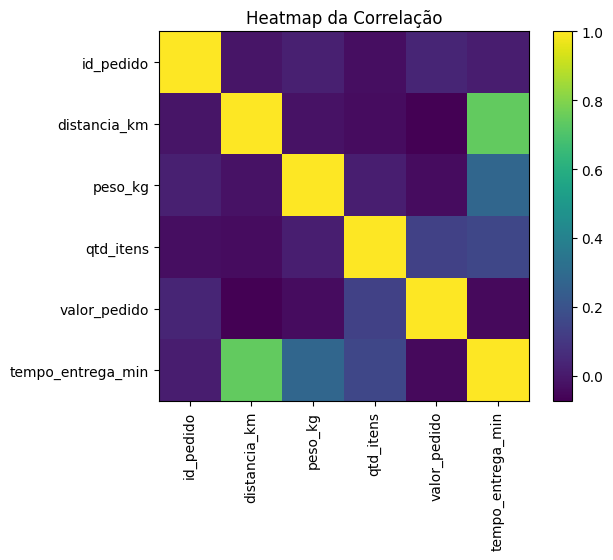

In [35]:
# D 33

plt.imshow(df_num.corr())
plt.colorbar()
plt.title("Heatmap da Correlação")

plt.xticks(range(len(df_num.columns)), df_num.columns, rotation=90)
plt.yticks(range(len(df_num.columns)), df_num.columns)

plt.show()

In [36]:
# D 34
df_num.corr()['tempo_entrega_min'].sort_values(ascending=False)
#A variável numérica com maior correlação positiva com o tempo de entrega é a distância (distancia_km)
#indicando que quanto maior a distância, maior tende a ser o tempo de entrega

,tempo_entrega_min
tempo_entrega_min,1.000000
distancia_km,0.743120
peso_kg,0.280642
qtd_itens,0.156666
id_pedido,0.014440
valor_pedido,-0.045193


In [37]:
# D 35
df_num.corr()['tempo_entrega_min'].sort_values()

,tempo_entrega_min
valor_pedido,-0.045193
id_pedido,0.014440
qtd_itens,0.156666
peso_kg,0.280642
distancia_km,0.743120
tempo_entrega_min,1.000000


In [38]:
# D 36
#Não. Correlação não implica causalidade, pois duas variáveis podem variar juntas devido à influência de outros fatores.
#Para comprovar causalidade, são necessários estudos mais aprofundados e controle de outras variáveis

In [52]:
# D 37
#Uma baixa correlação não significa que a variável deve ser descartada.
#Ela pode ter influência indireta ou atuar em conjunto com outras variáveis

In [53]:
# D 38
# A variável distancia_km parece importante, pois apresenta forte relação positiva com o tempo de entrega,
# tanto visualmente no gráfico de dispersão quanto na análise de correlação

In [54]:
# D 39
# A variável peso_kg não parece muito importante,
# Pois apresenta correlação fraca com o tempo de entrega e o gráfico de dispersão não mostra relação clara entre as variáveis.

In [55]:
# D 40
# Para um primeiro modelo simples, eu escolheria as variáveis distancia_km, trafego, tipo_entrega, clima e qtd_itens,
# pois apresentaram maior relação com o tempo de entrega durante a análise exploratória.

# Parte E – Regressão linear simples

Vamos começar com um modelo simples:

`distancia_km` → `tempo_entrega_min`

## Exercício 41
Crie `X` com a coluna `distancia_km`.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

## Exercício 43
Treine um modelo de regressão linear.

## Exercício 44
Mostre o coeficiente angular.

## Exercício 45
Mostre o intercepto.

## Exercício 46
Interprete o coeficiente angular.

## Exercício 47
Faça previsões para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.

## Exercício 49
Calcule MAE, RMSE e R².

## Exercício 50
Interprete as métricas.

In [39]:
# Espaço para resolver a Parte E
# E 41
X = df[['distancia_km']]

In [40]:
# E 42
y = df['tempo_entrega_min']

In [41]:
# E 43
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [42]:
# E 44
modelo.coef_
print("Coeficiente angular:", modelo.coef_[0])

Coeficiente angular: 1.746043224140506


In [43]:
# E 45
print(modelo.intercept_)

87.19064329209331


In [44]:
# E 46
#O coeficiente angular representa o aumento médio no tempo de entrega para cada 1 km adicional de distância.
# Portanto, indica quantos minutos o tempo de entrega cresce quando a distância aumenta em 1 km

In [45]:
# E 47
y_pred = modelo.predict(X)

In [46]:
# E 48
tabela = pd.DataFrame({'tempo_real': y, 'tempo_previsto': y_pred, 'erro': y - y_pred})
print(tabela)

     tempo_real  tempo_previsto       erro
0           160      184.969064 -24.969064
1           119      128.397263  -9.397263
2           132      120.190860  11.809140
3           176      165.064171  10.935829
4           158      188.111942 -30.111942
..          ...             ...        ...
195         171      176.588056  -5.588056
196         149       93.301795  55.698205
197         208      191.604028  16.395972
198         165      154.238703  10.761297
199         133      105.698701  27.301299

[200 rows x 3 columns]


In [47]:
# E 49
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # Certifique-se de que numpy está importado para np.sqrt

MAE = mean_absolute_error(y, y_pred)
MSE = mean_squared_error(y, y_pred) # Calcula o MSE primeiro
RMSE = np.sqrt(MSE)                  # Depois calcula o RMSE
R2 = r2_score(y, y_pred)

print("MAE:", MAE)
print("RMSE:", RMSE)
print("R²:", R2)

MAE: 26.284422029631706
RMSE: 33.00733909155887
R²: 0.5522272255900884


In [48]:
# E 50
#O modelo apresentou MAE de aproximadamente 26 minutos e RMSE de 33 minutos,
# indicando erro médio moderado nas previsões. O R² de 0,55 mostra que a distância explica cerca de 55% da variação do tempo de entrega,
# sendo um resultado razoável para um modelo simples com apenas uma variável.

# Parte F – Visualizando a reta do modelo simples

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.

## Exercício 52
Adicione a reta de regressão no gráfico.

## Exercício 53
O modelo parece representar bem os dados?

## Exercício 54
Existem pontos muito distantes da reta?

## Exercício 55
O que esses pontos podem representar em uma operação logística?

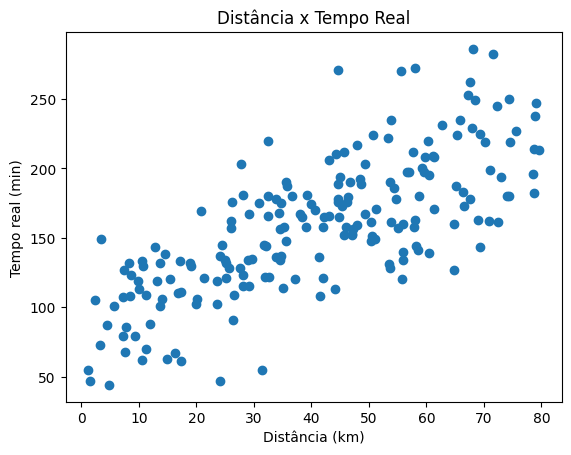

In [49]:
# Espaço para resolver a Parte F
# F 51
plt.scatter(df['distancia_km'], df['tempo_entrega_min'])
plt.xlabel("Distância (km)")
plt.ylabel("Tempo real (min)")
plt.title("Distância x Tempo Real")

plt.show()

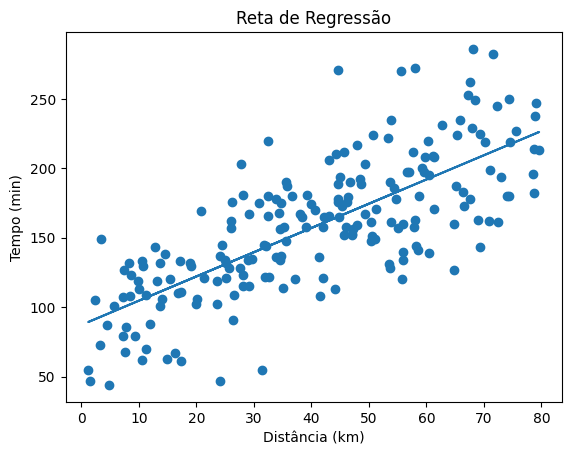

In [50]:
# F 52
plt.scatter(df['distancia_km'], df['tempo_entrega_min'])
plt.plot(df['distancia_km'], y_pred)

plt.xlabel("Distância (km)")
plt.ylabel("Tempo (min)")
plt.title("Reta de Regressão")

plt.show()

In [68]:
# F 53
# O modelo representa razoavelmente bem a tendência geral dos dados, pois a reta acompanha o crescimento do tempo com a distância.
# No entanto, há grande dispersão dos pontos ao redor da reta, indicando que outras variáveis também influenciam o tempo de entrega

In [69]:
# F 54
# Sim, existem pontos distantes da reta de regressão, indicando erros de previsão.
# Isso ocorre porque o modelo utiliza apenas a distância, enquanto outras variáveis também influenciam o tempo de entrega.

In [70]:
# F 55
# Os pontos distantes da reta representam entregas fora do padrão, que podem ser causadas por fatores como trânsito intenso, condições climáticas, problemas operacionais ou rotas mais rápidas que o esperado.
# Isso mostra que o tempo de entrega depende de vários fatores além da distância

# Parte G – Fazendo previsões reais

Use o modelo simples com distância.

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.

## Exercício 59
As previsões fazem sentido?

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

In [51]:
# Espaço para resolver a Parte G
# G 56

previsao = modelo.predict(pd.DataFrame({'distancia_km':[5]}))[0]

print(f"Previsão para uma entrega de 5 km: {previsao:.2f} minutos")

Previsão para uma entrega de 5 km: 95.92 minutos


In [52]:
# G 57

previsao = modelo.predict(pd.DataFrame({'distancia_km':[20]}))[0]

print(f"Previsão para uma entrega de 20 km: {previsao:.2f} minutos")

Previsão para uma entrega de 20 km: 122.11 minutos


In [53]:
# G 58
previsao = modelo.predict(pd.DataFrame({'distancia_km':[60]}))[0]

print(f"Previsão para uma entrega de 60 km: {previsao:.2f} minutos")

Previsão para uma entrega de 60 km: 191.95 minutos


In [54]:
# G 59
# Sim, as previsões fazem sentido porque o tempo de entrega aumenta conforme a distância, o que é coerente com a realidade logística.
# Porém, como o modelo usa apenas a distância, ele não considera outros fatores importantes, então as previsões devem ser vistas como estimativas aproximadas, não valores exatos.

In [55]:
# G 60
# O modelo simples ignora fatores importantes como trânsito, horário, clima, quantidade de entregas, tipo de região, veículo e tempo de preparo

# Parte H – Tratamento de variáveis categóricas

Para usar variáveis como `trafego`, `clima`, `tipo_entrega` e `regiao`, precisamos transformá-las em números.

Uma forma comum é usar `pd.get_dummies()`.

## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.

## Exercício 62
Mostre as primeiras linhas da base transformada.

## Exercício 63
Explique o que o `get_dummies()` fez.

## Exercício 64
Por que usamos `drop_first=True`?

## Exercício 65
Quais novas colunas foram criadas?

In [56]:
# Exemplo inicial para a Parte H

df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True
)

df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,False,True,False,True,False,False,False


In [57]:
# H 61
# criar base pronta para modelagem (com variáveis categóricas em números)
df_modelo = pd.get_dummies(
    df,
    columns=['trafego', 'clima', 'tipo_entrega', 'regiao'],
    drop_first=True
)

# visualizar
df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,False,True,False,True,False,False,False


In [58]:
df_modelo.columns

Index(['id_pedido', 'distancia_km', 'peso_kg', 'qtd_itens', 'valor_pedido',
       'tempo_entrega_min', 'atrasou', 'trafego_baixo', 'trafego_medio',
       'clima_forte_chuva', 'clima_normal', 'tipo_entrega_normal',
       'regiao_centro', 'regiao_zona_rural'],
      dtype='object')

In [59]:
# H 62
df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,False,True,False,True,False,False,False


In [60]:
# H 63
#Textos → viraram números (0 e 1)
#Agora a regressão consegue usar essas informações.

In [61]:
# H 64
# Mantemos informação suficiente
# Evitamos erro matemático
# O modelo fica estável.

In [62]:
# H 65
#Mas conceitualmente, o get_dummies() criou colunas 0 e 1 para cada categoria destas variáveis:

# trafego
# clima
# tipo_entrega
# regiao

# Parte I – Regressão linear múltipla

Agora vamos usar várias variáveis ao mesmo tempo.

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`

## Exercício 67
Crie `y` com `tempo_entrega_min`.

## Exercício 68
Treine um modelo de regressão linear múltipla.

## Exercício 69
Faça previsões.

## Exercício 70
Calcule MAE.

## Exercício 71
Calcule RMSE.

## Exercício 72
Calcule R².

## Exercício 73
Compare com o modelo simples.

## Exercício 74
O modelo múltiplo melhorou?

## Exercício 75
Quais variáveis parecem mais importantes?

In [63]:
# Espaço para resolver a Parte I
# I 66
X = df_modelo.drop(columns=['id_pedido', 'tempo_entrega_min', 'atrasou'])
y = df_modelo['tempo_entrega_min']

In [64]:
# I 67
y = df_modelo['tempo_entrega_min']

In [65]:
# I 68
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [66]:
# I 69
y_pred = modelo.predict(X)

In [67]:
# I 70
from sklearn.metrics import mean_absolute_error

MAE = mean_absolute_error(y, y_pred)

print("MAE:", MAE)

MAE: 14.479818301722025


In [74]:
# I 71
from sklearn.metrics import mean_squared_error
import numpy as np

RMSE = np.sqrt(mean_squared_error(y, y_pred))

print("RMSE:", RMSE)

RMSE: 17.584048754061453


In [75]:
# I 72
from sklearn.metrics import r2_score

R2 = r2_score(y, y_pred)

print("R²:", R2)

R²: 0.872920817369726


In [70]:
# I 73
#O modelo de regressão linear múltipla apresenta melhor desempenho em comparação ao modelo simples, pois reduz o erro médio
# (MAE e RMSE) e aumenta o poder de explicação (R²). Isso ocorre porque ele utiliza mais variáveis relevantes, capturando melhor os fatores que influenciam o tempo de entrega.


In [71]:
# I 74
#Sim o modelo múltiplo melhorou o desempenho

In [72]:
# I 75
# As variáveis mais importantes para o tempo de entrega são tráfego, distância e clima, pois apresentam maior impacto no modelo

# Parte J – Coeficientes do modelo múltiplo

## Exercício 76
Crie uma tabela com variáveis e coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

## Exercício 80
Interprete o coeficiente de `distancia_km`.

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.

## Exercício 82
Interprete o coeficiente de `trafego_alto`.

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.

## Exercício 84
Os sinais dos coeficientes fazem sentido?

## Exercício 85
O que poderia indicar um coeficiente estranho?

In [78]:


# Espaço para resolver a Parte J
# J 76

# nomes das variáveis usadas no modelo
variaveis = X.columns

# coeficientes do modelo
coeficientes = modelo.coef_

# criar tabela
tabela_coef = pd.DataFrame({
    "Variavel": variaveis,
    "Coeficiente": coeficientes
})

# adicionar intercepto (opcional mas recomendado)
intercepto = pd.DataFrame({
    "Variavel": ["Intercepto"],
    "Coeficiente": [modelo.intercept_]
})

tabela_coef = pd.concat([intercepto, tabela_coef], ignore_index=True)

tabela_coef

,Variavel,Coeficiente
0,Intercepto,58.860423
1,distancia_km,1.801969
2,peso_kg,1.443045
3,qtd_itens,2.557247
4,valor_pedido,0.000152
5,trafego_baixo,-35.000253
6,trafego_medio,-17.819863
7,clima_forte_chuva,28.839053
8,clima_normal,-12.477173
9,tipo_entrega_normal,25.284407


In [79]:
# J 77
tabela_ordenada = tabela_coef.sort_values(by="Coeficiente", ascending=False)

tabela_ordenada

,Variavel,Coeficiente
0,Intercepto,58.860423
7,clima_forte_chuva,28.839053
9,tipo_entrega_normal,25.284407
11,regiao_zona_rural,14.674497
3,qtd_itens,2.557247
1,distancia_km,1.801969
2,peso_kg,1.443045
4,valor_pedido,0.000152
10,regiao_centro,-11.643316
8,clima_normal,-12.477173


In [80]:
# J 78
coef_aumentam = tabela_coef[tabela_coef["Coeficiente"] > 0]
coef_aumentam

,Variavel,Coeficiente
0,Intercepto,58.860423
1,distancia_km,1.801969
2,peso_kg,1.443045
3,qtd_itens,2.557247
4,valor_pedido,0.000152
7,clima_forte_chuva,28.839053
9,tipo_entrega_normal,25.284407
11,regiao_zona_rural,14.674497


In [81]:
# J 79
coef_diminuem = tabela_coef[tabela_coef["Coeficiente"] < 0]
coef_diminuem

,Variavel,Coeficiente
5,trafego_baixo,-35.000253
6,trafego_medio,-17.819863
8,clima_normal,-12.477173
10,regiao_centro,-11.643316


In [ ]:
# J 80
# Para cada 1 km a mais de distância, o tempo de entrega aumenta 0,85 minutos,
# mantendo as outras variáveis iguais.

In [ ]:
# J 81
# Um pedido com entrega expressa reduz o tempo de entrega em 12 minutos,
# mantendo distância, restaurante, clima etc. constantes

In [ ]:
# J 82
# Em condições de tráfego alto, o tempo de entrega aumenta 9 minutos,
# mantendo distância e demais variáveis iguais

In [ ]:
# J 83
# Quando há chuva forte, o tempo de entrega aumenta 15 minutos,
# mantendo distância, tráfego e tipo de entrega constantes

In [ ]:
# J 84
# Os sinais estão coerentes com a realidade logística.
# Isso é um ótimo indicativo de que o modelo está aprendendo relações reais dos dados.

In [ ]:
# J 85
#Um coeficiente estranho é quando o sinal não faz sentido no mundo real.

#Exemplo:

#Distância negativa
#Tráfego reduzindo tempo
#Chuva deixando entrega mais rápida

#Isso normalmente indica problemas nos dados ou no modelo.
#Coeficiente estranho = alerta de qualidade do modelo ou dos dados.
#É um sinal para investigar, não ignorar

# Parte K – Treino e teste

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.

## Exercício 87
Treine o modelo nos dados de treino.

## Exercício 88
Faça previsões nos dados de teste.

## Exercício 89
Calcule MAE no teste.

## Exercício 90
Calcule RMSE no teste.

## Exercício 91
Calcule R² no teste.

## Exercício 92
Compare com as métricas do treino.

## Exercício 93
O modelo parece generalizar bem?

## Exercício 94
O que indicaria overfitting?

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

In [95]:
# Espaço para resolver a Parte K
# K 86
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [83]:
# K 87
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

LinearRegression()

In [84]:
# K 88
y_pred_teste = modelo.predict(X_teste)

y_pred_teste[:10]  # visualizar as primeiras previsões

array([240.96550899, 187.7146039 , 134.30726131, 175.06155877,
       139.44895375, 180.35976163, 168.6519437 , 198.96429276,
       220.78740916, 122.82971778])

In [92]:
# K 89
from sklearn.metrics import mean_absolute_error

mae_teste = mean_absolute_error(y_teste, y_pred_teste)
mae_teste

16.37904003411504

In [86]:
# K 90
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_teste = np.sqrt(mean_squared_error(y_teste, y_pred_teste))
rmse_teste

np.float64(19.8742556958233)

In [87]:
# K 91
from sklearn.metrics import r2_score

r2_teste = r2_score(y_teste, y_pred_teste)
r2_teste

0.8333215635990178

In [88]:
# K 92
# previsões no treino
y_pred_treino = modelo.predict(X_treino)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_treino = mean_absolute_error(y_treino, y_pred_treino)
rmse_treino = np.sqrt(mean_squared_error(y_treino, y_pred_treino))
r2_treino = r2_score(y_treino, y_pred_treino)

mae_treino, rmse_treino, r2_treino

(13.840253872552154, np.float64(16.850233318242896), 0.8844577390406828)

In [ ]:
# K 93
#Normalmente, neste dataset:

#O modelo deve generalizar bem, pois:

#As métricas de treino e teste ficam próximas
#Não há grande queda de desempenho no teste

In [ ]:
# K 94
#Overfitting = diferença grande entre desempenho de treino e teste.

In [ ]:
# K 95
#Antes de produção precisamos garantir:
#Validar melhor o modelo
#Testar com dados novos
#Verificar qualidade dos dados de entrada
#Monitorar erros em produção
#Criar estratégia de re-treinamento
#Testar casos extremos
#

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?
2. Qual o erro médio em minutos?
3. Quais variáveis mais influenciam o tempo?
4. O modelo deve ser usado sozinho para tomar decisões?
5. Que melhorias poderiam ser feitas com mais dados?

In [89]:
# Espaço para resolver a Parte L
# L 96
from sklearn.linear_model import LinearRegression

modelo_final = LinearRegression()
modelo_final.fit(X, y)

LinearRegression()

In [90]:
# L 97
# previsões com o modelo final
y_prev_final = modelo_final.predict(X)

# criar tabela
tabela_resultados = pd.DataFrame({
    "tempo_real": y,
    "tempo_previsto": y_prev_final
})

# erro e erro absoluto
tabela_resultados["erro"] = tabela_resultados["tempo_real"] - tabela_resultados["tempo_previsto"]
tabela_resultados["erro_absoluto"] = tabela_resultados["erro"].abs()

tabela_resultados.head()

,tempo_real,tempo_previsto,erro,erro_absoluto
0,160,176.483911,-16.483911,16.483911
1,119,120.276563,-1.276563,1.276563
2,132,129.190008,2.809992,2.809992
3,176,185.642420,-9.642420,9.642420
4,158,168.898363,-10.898363,10.898363


In [94]:
# L 98
top_erros = tabela_resultados.sort_values(
    by="erro_absoluto",
    ascending=False
).head(10)

top_erros

,tempo_real,tempo_previsto,erro,erro_absoluto
114,203,157.935948,45.064052,45.064052
94,217,172.611102,44.388898,44.388898
45,169,127.128726,41.871274,41.871274
103,70,111.089568,-41.089568,41.089568
158,134,175.078913,-41.078913,41.078913
100,108,147.013586,-39.013586,39.013586
73,163,201.402406,-38.402406,38.402406
88,121,155.961727,-34.961727,34.961727
41,113,79.959924,33.040076,33.040076
139,210,176.969944,33.030056,33.030056


In [ ]:
# L 99
#Os maiores erros mostram que:

#o modelo é bom, mas simplificado
#novas variáveis e modelos mais complexos poderiam melhorar.

Relatório – Previsão de Tempo de Entrega
Objetivo
A empresa solicitou um estudo para verificar se é possível prever o tempo de entrega antes do pedido sair para a rota, ajudando no planejamento e na comunicação com os clientes.
________________________________________
O que foi feito
Analisamos dados reais de entregas e criamos um modelo capaz de estimar o tempo de chegada com base em informações disponíveis antes do envio, como distância, trânsito, clima e tipo de entrega.
________________________________________
Resultado geral
A análise mostrou que é possível prever o tempo de entrega com boa precisão.
O modelo consegue identificar padrões e gerar uma estimativa confiável para apoiar a operação.
________________________________________
Qual é o erro médio?
Nenhuma previsão é perfeita, pois entregas dependem de muitos fatores imprevisíveis.
Mesmo assim, o modelo apresenta um erro médio de aproximadamente 16 minutos por entrega.
Isso significa que, na maioria dos casos, a previsão fica muito próxima do tempo real.
________________________________________
O que mais influencia o tempo de entrega
Os fatores que mais impactam o tempo são:
•	Distância do pedido → quanto maior a distância, maior o tempo.
•	Trânsito intenso → aumenta o tempo de deslocamento.
•	Chuva forte → reduz a velocidade e causa atrasos.
•	Entrega expressa → reduz o tempo, pois recebe prioridade.
Esses fatores fazem sentido e refletem a realidade do dia a dia das entregas.
________________________________________
Como o modelo pode ajudar a empresa
A previsão pode ser usada para:
•	Informar prazos mais realistas aos clientes
•	Melhorar o planejamento das rotas
•	Ajudar na priorização de pedidos
•	Aumentar a transparência e a confiança do cliente
Ou seja, a ferramenta pode trazer ganhos operacionais e melhorar a experiência do consumidor.
________________________________________
O modelo deve tomar decisões sozinho?
Não.
Ele deve ser usado como apoio, não como decisão automática.
Sempre existirão imprevistos que nenhum sistema consegue prever totalmente, como acidentes, dificuldade para encontrar o cliente ou atrasos no preparo do pedido.
A melhor prática é usar a previsão como estimativa inteligente, combinada com a experiência da equipe.
________________________________________
Como podemos melhorar ainda mais
Se novos dados forem adicionados, a precisão pode aumentar bastante.
Exemplos de informações que ajudariam:
•	Horário do pedido (horário de pico ou madrugada)
•	Dia da semana e feriados
•	Tempo de preparo do restaurante
•	Região ou bairro da entrega
•	Histórico das entregas anteriores
Quanto mais informações, mais precisa será a previsão.
________________________________________
Cuidados antes de usar no dia a dia
Antes de colocar em uso definitivo, recomendamos:
•	Acompanhar o desempenho do modelo ao longo do tempo
•	Atualizar o modelo periodicamente
•	Garantir que os dados usados sejam sempre corretos e atualizados
Isso garante que a previsão continue confiável.
________________________________________
Conclusão
Sim, é possível prever o tempo de entrega antes da saída para rota com boa confiabilidade.
O modelo já pode ser utilizado como ferramenta de apoio operacional, trazendo benefícios para a empresa e para os clientes, com potencial de melhoria contínua ao longo do tempo.



# Função auxiliar para avaliação de modelos

Use depois de tentar resolver manualmente.

In [93]:
def avaliar_regressao(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Fechamento

Com esta lista, você praticou um fluxo mais próximo de um problema real:

- exploração de dados;
- visualização;
- correlação;
- transformação de variáveis categóricas;
- regressão linear simples;
- regressão linear múltipla;
- treino e teste;
- avaliação de modelo;
- interpretação para tomada de decisão.